<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/Template_for_Modelling_EEG_signals_using_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
sns.set_theme(context='notebook',
              style='white',
              palette='deep',
              font='Lucida Calligraphy',
              font_scale=1.5,
              color_codes=True,
              rc=None)
import matplotlib

plt.rcParams['figure.figsize'] = (14,8)
plt.rcParams['figure.facecolor'] = '#F0F8FF'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.edgecolor'] = 'green'
plt.rcParams['figure.frameon'] = True

plt.rcParams["figure.autolayout"] = True

plt.rcParams['axes.facecolor'] = '#F5F5DC'
plt.rcParams['axes.titlesize'] = 25
plt.rcParams["axes.titleweight"] = 'normal'
plt.rcParams["axes.titlecolor"] = 'Olive'
plt.rcParams['axes.edgecolor'] = 'pink'
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.grid"] = True
plt.rcParams['axes.titlelocation'] = 'center'
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.labelpad"] = 2
plt.rcParams['axes.labelweight'] = 1
plt.rcParams["axes.labelcolor"] = 'Olive'
plt.rcParams["axes.axisbelow"] = False
plt.rcParams['axes.xmargin'] = .2
plt.rcParams["axes.ymargin"] = .2

plt.rcParams["xtick.bottom"] = True
plt.rcParams['xtick.color'] = '#A52A2A'
plt.rcParams["ytick.left"] = True
plt.rcParams['ytick.color'] = '#A52A2A'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'green'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = .5
plt.rcParams['grid.alpha'] = .3

plt.rcParams['legend.loc'] = 'best'
plt.rcParams['legend.facecolor'] =  'NavajoWhite'
plt.rcParams['legend.edgecolor'] = 'pink'
plt.rcParams['legend.shadow'] = True
plt.rcParams['legend.fontsize'] = 20


plt.rcParams['font.family'] = 'Lucida Calligraphy'
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.edgecolor'] = 'Blue'

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv")

In [ ]:
df.head()
df.columns=["Time","Prefrontal Cortex_EEG","Auditory Cortex_EEG","Sound Signal"]

<Figure size 2100x1200 with 0 Axes>

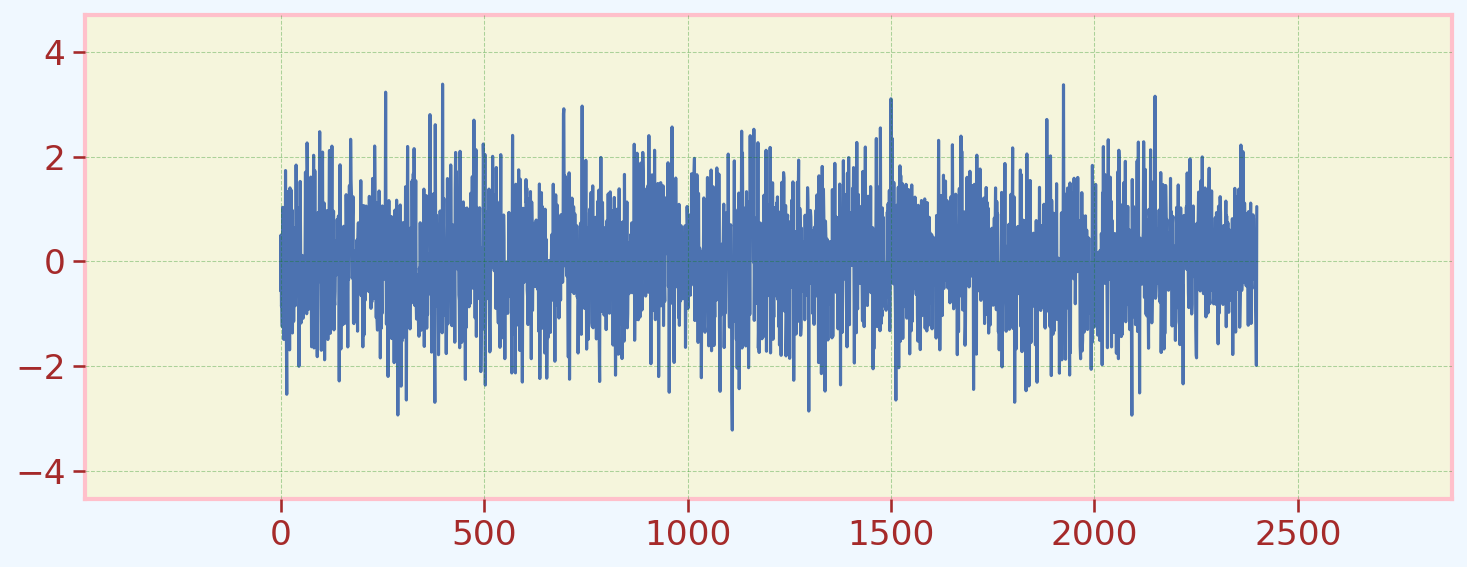

In [ ]:
fig=plt.figure()
plt.figure(figsize = (10,4))
plt.plot(df["Prefrontal Cortex_EEG"])
plt.show()

In [ ]:
fig.savefig('prefrontal_EEG.png')

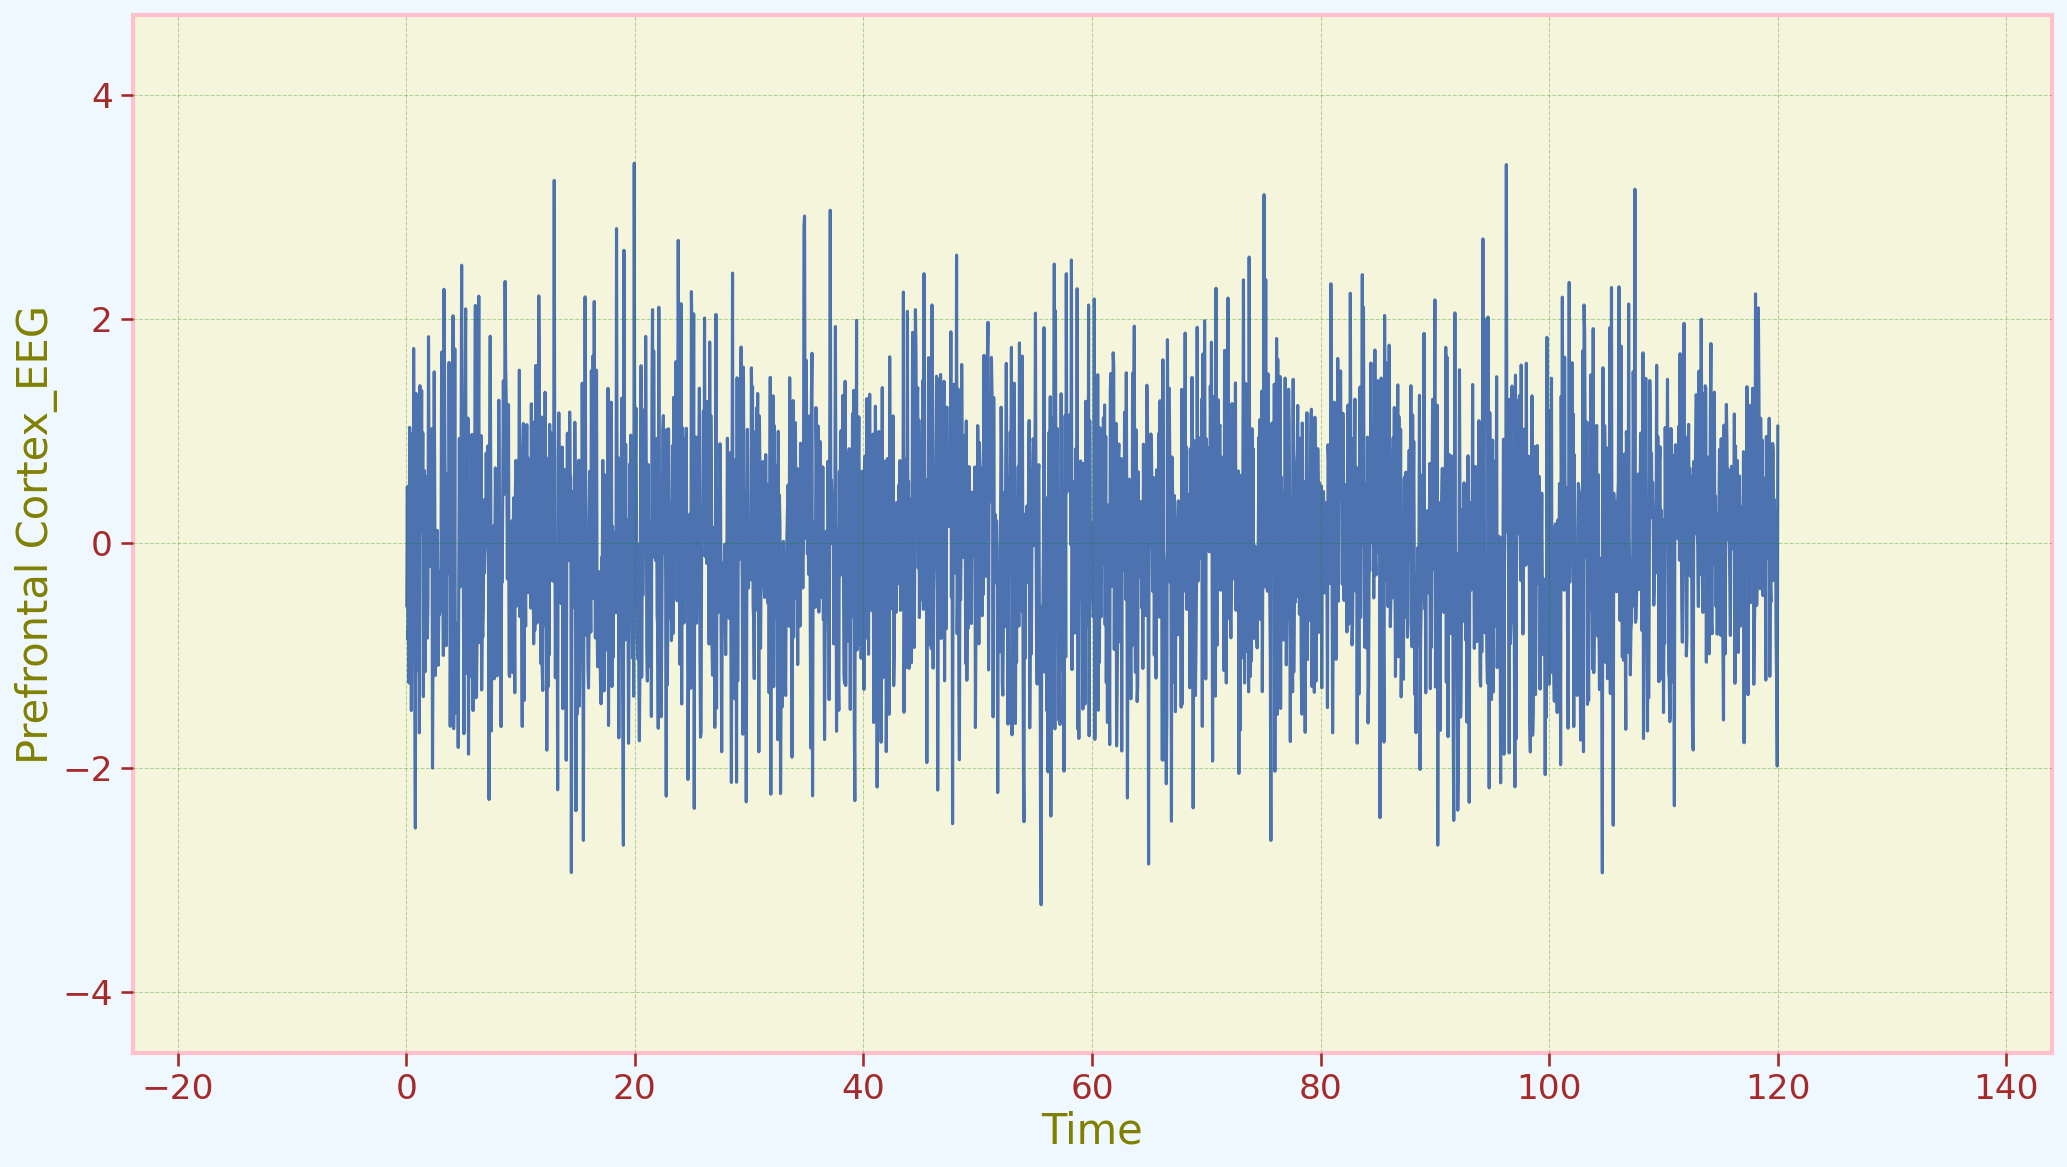

In [ ]:
fig=plt.figure()
sns.lineplot(data=df,x="Time", y="Prefrontal Cortex_EEG")
fig.savefig('prefrontal_EEG.png')

## Distribution plots

<Figure size 2100x1200 with 0 Axes>

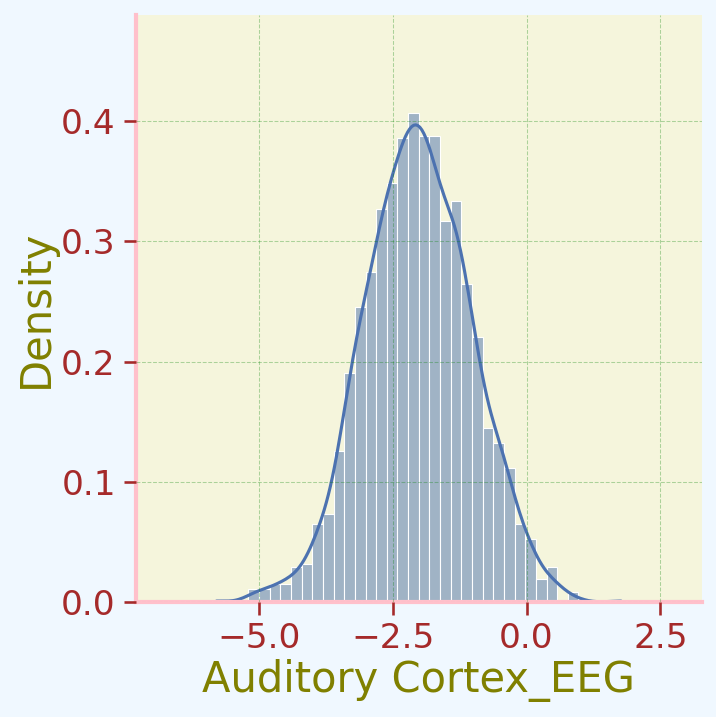

In [ ]:
fig=plt.figure()
sns.displot(df["Auditory Cortex_EEG"],stat = 'density',kde = True)
fig.savefig("Auditory_distribution.png")

## Correlation Analysis

In [ ]:
(df.iloc[:,1:4].corr())

,Prefrontal Cortex_EEG,Auditory Cortex_EEG,Sound Signal
Prefrontal Cortex_EEG,1.000000,-0.024313,0.862507
Auditory Cortex_EEG,-0.024313,1.000000,-0.252638
Sound Signal,0.862507,-0.252638,1.000000


## Scatter plot

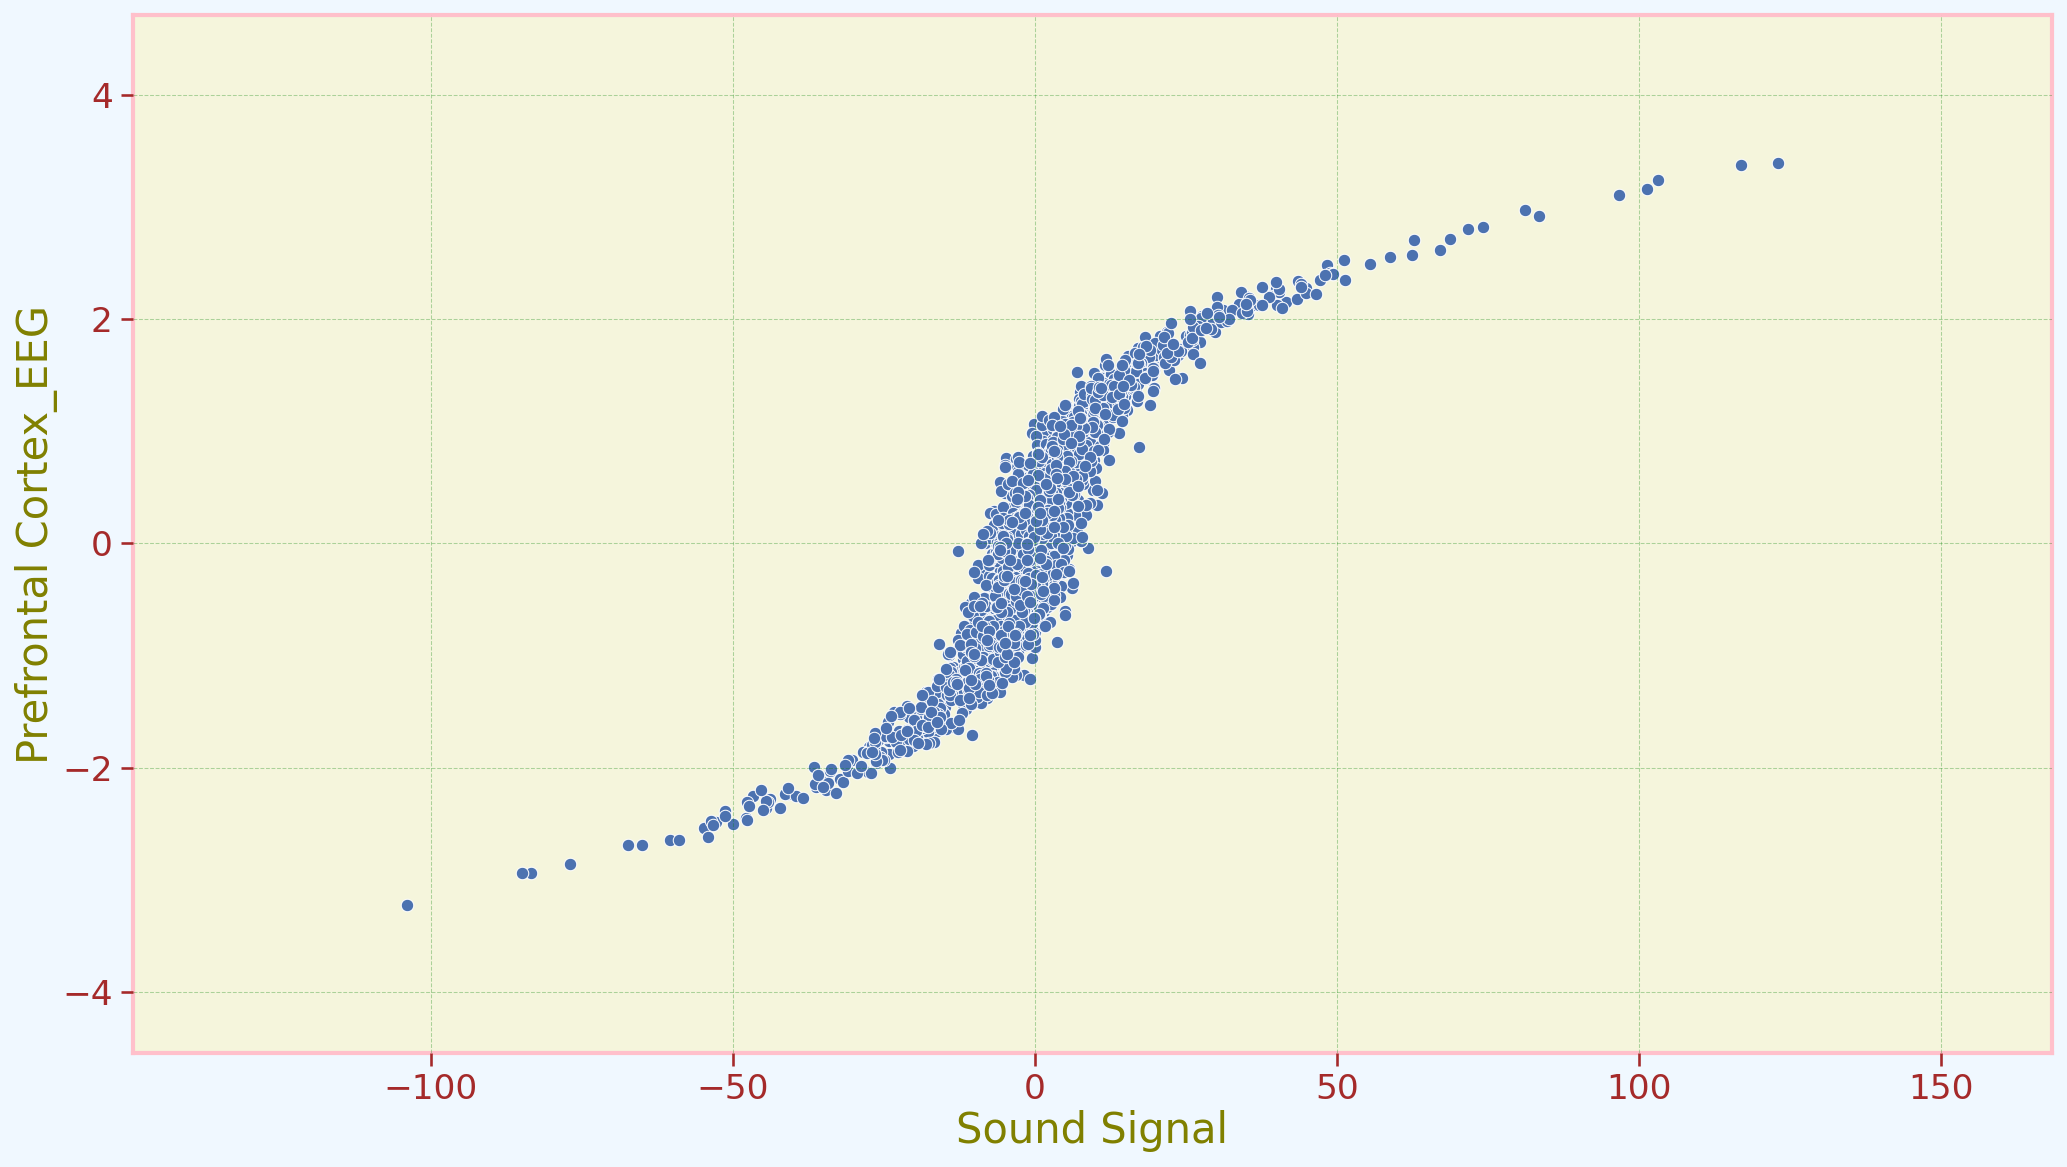

In [ ]:
fig=plt.figure()
sns.scatterplot(data=df, x="Sound Signal", y="Prefrontal Cortex_EEG")
# displaying heatmap
fig.savefig("ScatterPlotPCortex.png")


In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv")

In [ ]:
df.head()

,time,x1,x2,y
0,0.05,-0.562320,-2.274491,-2.386526
1,0.10,0.505550,-1.451586,-0.371560
2,0.15,-0.857812,-0.271215,-12.586452
3,0.20,-0.735262,-3.402501,-0.248121
4,0.25,-1.244369,-2.199162,-10.681437


Model 1: $y = θ_1x_1^3 + θ_2x_2^5 + \theta_{bias} + \epsilon$

---



In [ ]:
X1 = np.column_stack((df["x1"]**3,df["x2"]**5 ,np.ones(len(df["x1"]))))

In [ ]:
y=df["y"]

In [ ]:
X=X1

In [ ]:
## creating OLS model using statmodels
import statsmodels.api as sm
import pandas
# Note the difference in argument order
model = sm.OLS(y, sm.add_constant(X)).fit()
predictions = model.predict(X) # make the predictions by the model

# Print out the statistics
print(model.summary())

In [ ]:
print("RSS:",model.ssr)

In [ ]:
# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T,X)),X.T)),y)
print(alpha)

[ 3.59670957 -0.00588119 -1.14962247]


In [ ]:
yp=np.dot(alpha,X.T)


In [ ]:
yp

array([ -1.43114128,  -0.64699082,  -3.41990307, ...,  -7.59611993,
       -28.99507223,   2.99010508])

In [ ]:
RSS=np.sum(np.square(y-yp))
RSS

30738.220491484455

In [ ]:
# function to calculate RSS
def RSS(y, y_hat):
  total_RSS = 0.
  for y_, y_hat_ in zip(y, y_hat):
  	total_RSS+= (y_ - y_hat_)**2
  return total_RSS

In [ ]:
rss=RSS(y,yp)

In [ ]:
rss

30738.22049148441

In [ ]:
len(df["x1"])

2400

In [ ]:
from math import log
llf=-len(df["x1"])/2*log(2*np.pi)-len(df["x1"])/2*log(rss/(len(df["x1"])-1))-(len(df["x1"])-1)/2

In [ ]:
llf

-6465.498315958332

In [ ]:
k=len(alpha)
k

3

In [ ]:
AIC=(2*k)-2*llf
AIC

12936.996631916663

In [ ]:
BIC=k*log(len(df["x1"]))-2*llf
BIC

12954.34630396567

In [ ]:
res=y-yp
sm.qqplot(np.array(res),line='s')
plt.show()

NameError: ignored